In [2]:
# importing neccessary library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import random
from tqdm import tqdm
import warnings
import random
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

2026-01-22 17:37:49.345433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769103469.542903      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769103469.599829      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769103470.087375      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769103470.087411      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769103470.087413      55 computation_placer.cc:177] computation placer alr

In [3]:
Alzheimer_df="/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images"

In [4]:

os.listdir(Alzheimer_df)

['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'MildDemented']

In [5]:
#Value count for the classes in the datasets
classes = ['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'MildDemented']
class_counts = {}

for class_name in classes:
    class_path = os.path.join(Alzheimer_df, class_name)
    num_images = len(os.listdir(class_path))
    class_counts[class_name] = num_images
    print(f"{class_name}: {num_images} images")

print(f"\nTotal images: {sum(class_counts.values())}")


ModerateDemented: 10000 images
NonDemented: 12800 images
VeryMildDemented: 11200 images
MildDemented: 10000 images

Total images: 44000


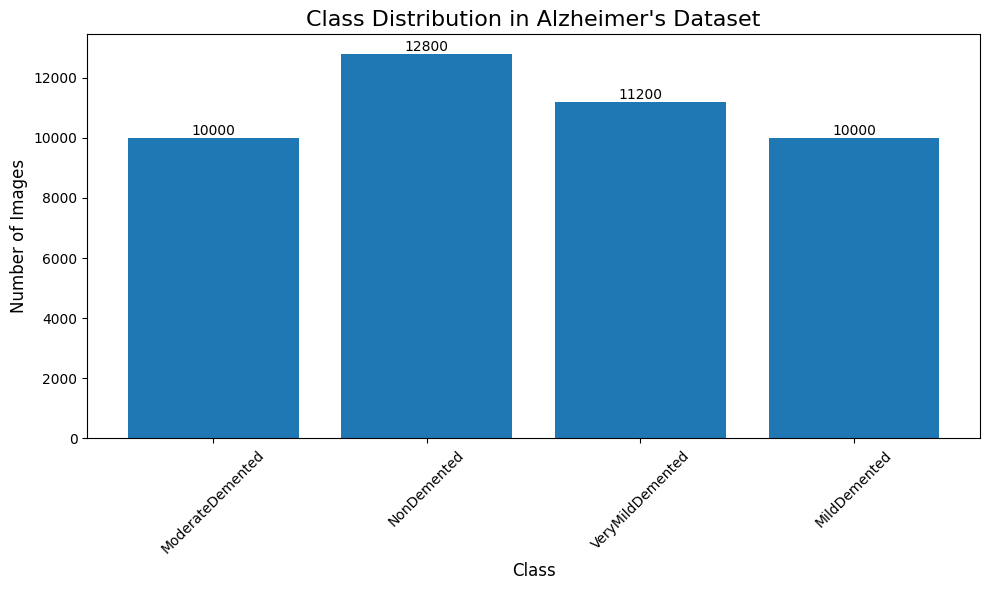

In [6]:
# Checking for the class distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(class_counts.keys(), class_counts.values())
plt.title('Class Distribution in Alzheimer\'s Dataset', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

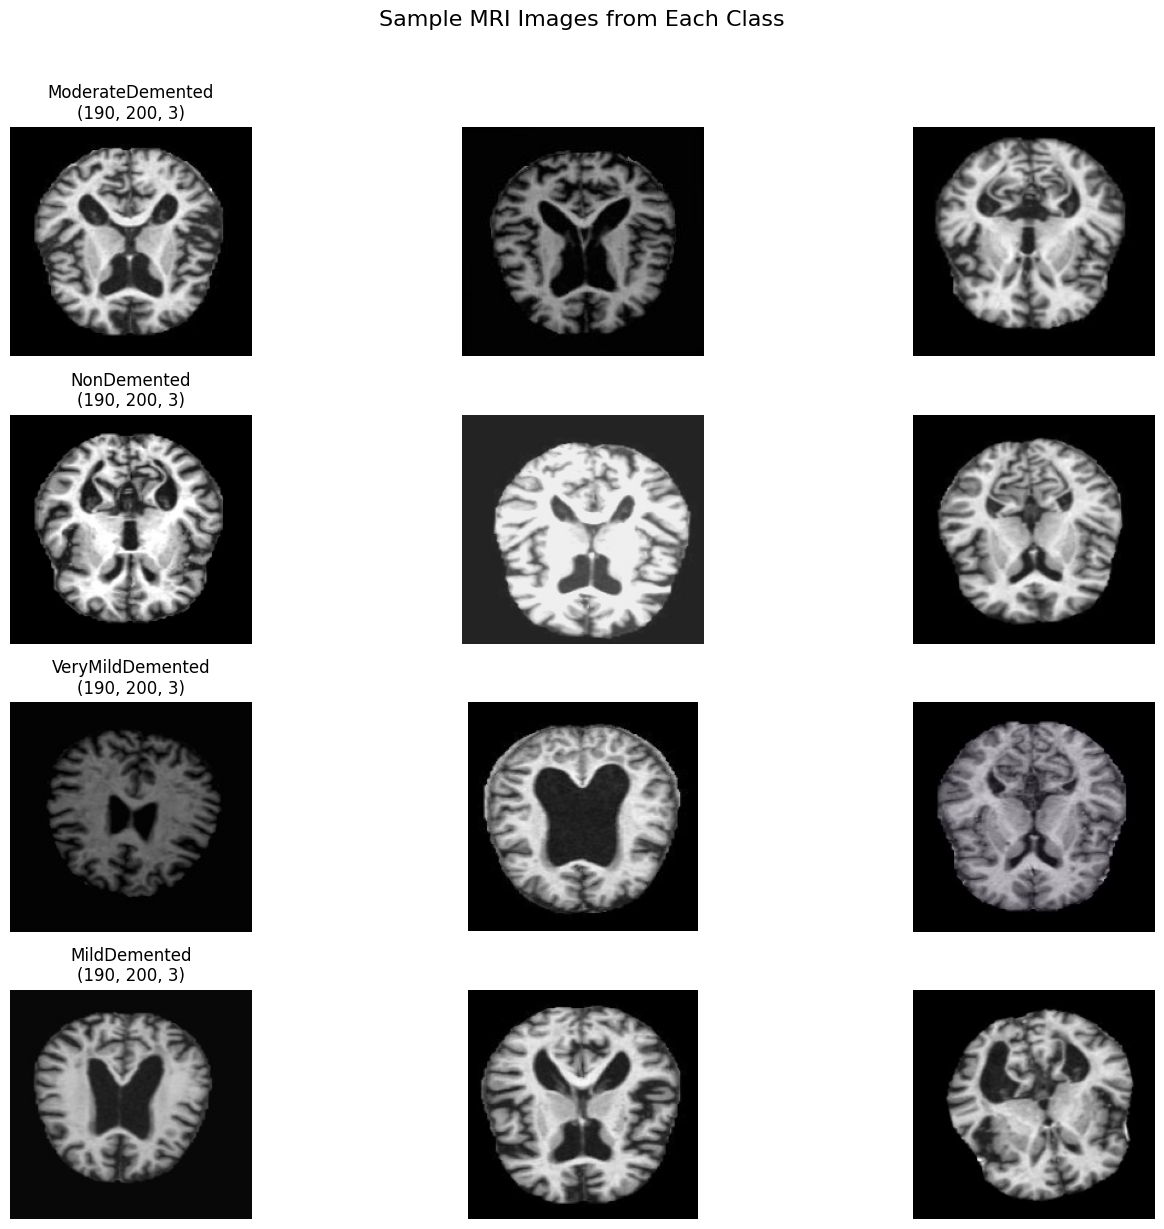

In [7]:
# Function to display 3 random MRI samples from each Alzheimer's severity class
def display_sample_images(Alzheimer_df, classes, samples_per_class=3):
    """
    Display sample images from each class
    """
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(15, 12))
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(Alzheimer_df, class_name)
        image_files = os.listdir(class_path)
        sample_files = random.sample(image_files, samples_per_class)
        
        for j, image_file in enumerate(sample_files):
            img_path = os.path.join(class_path, image_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f'{class_name}\n{img.shape}', fontsize=12)
    
    plt.suptitle('Sample MRI Images from Each Class', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


display_sample_images(Alzheimer_df, classes)

In [8]:
# Check if all images in a random Alzheimer severity class have consistent dimensions

sample_class = random.choice(classes)
sample_images = os.listdir(os.path.join(Alzheimer_df, sample_class))[:20]

shapes = []

for img_name in sample_images:
    img_path = os.path.join(Alzheimer_df, sample_class, img_name)
    img = cv2.imread(img_path)
    shapes.append(img.shape)

set(shapes)

{(190, 200, 3), (208, 176, 3)}

In [9]:
# Scan first 200 images per Alzheimer class to detect and count corrupted MRI files
corrupted = []

for cls in classes:
    class_path = os.path.join(Alzheimer_df, cls)
    for img_name in os.listdir(class_path)[:200]:  # sample check
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            corrupted.append(img_path)

print(f"Corrupted images found: {len(corrupted)}")

Corrupted images found: 0


In [10]:
# Build dataframe mapping all MRI image paths to their Alzheimer's severity labels
data = []

for class_idx, class_name in enumerate(classes):
    class_path = os.path.join(Alzheimer_df, class_name)
    for img_file in os.listdir(class_path):
        if img_file.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(class_path, img_file)
            data.append([img_path, class_name, class_idx])

df = pd.DataFrame(data, columns=['filepath', 'class_name', 'class_label'])

print(f"DataFrame shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# Check distribution in dataframe
print("\nClass distribution in DataFrame:")
print(df['class_name'].value_counts())

DataFrame shape: (44000, 3)

First few rows:
                                            filepath        class_name  \
0  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented   
1  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented   
2  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented   
3  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented   
4  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented   

   class_label  
0            0  
1            0  
2            0  
3            0  
4            0  

Class distribution in DataFrame:
class_name
NonDemented         12800
VeryMildDemented    11200
ModerateDemented    10000
MildDemented        10000
Name: count, dtype: int64


In [11]:
sample_images = []
for class_name in classes:
    class_folder = os.path.join(Alzheimer_df, class_name)
    all_images = os.listdir(class_folder)
    
    # Take 25 random images from each class
    random_images = random.sample(all_images, min(25, len(all_images)))
    
    for img_name in random_images:
        img_path = os.path.join(class_folder, img_name)
        sample_images.append(img_path)

print(f"Selected {len(sample_images)} random images to analyze")

Selected 100 random images to analyze


In [12]:
# Analyze dimensions of randomly sampled Alzheimer MRI images to determine size variabilit
heights = []
widths = []
dimension_pairs = []

for img_path in tqdm(sample_images, desc="Checking image sizes"):
    
    img = cv2.imread(img_path)
    
    
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)
    dimension_pairs.append(f"{h}x{w}")

print("\n--- Image Size Analysis ---")
print(f"Smallest height: {min(heights)} pixels")
print(f"Largest height: {max(heights)} pixels")
print(f"Smallest width: {min(widths)} pixels")
print(f"Largest width: {max(widths)} pixels")
print(f"Average height: {np.mean(heights):.1f} pixels")
print(f"Average width: {np.mean(widths):.1f} pixels")

Checking image sizes: 100%|██████████| 100/100 [00:00<00:00, 152.23it/s]


--- Image Size Analysis ---
Smallest height: 180 pixels
Largest height: 208 pixels
Smallest width: 176 pixels
Largest width: 200 pixels
Average height: 192.6 pixels
Average width: 194.5 pixels


Most common image sizes:
------------------------------
190x200: 76 images (76.0%)
208x176: 18 images (18.0%)
180x180: 6 images (6.0%)


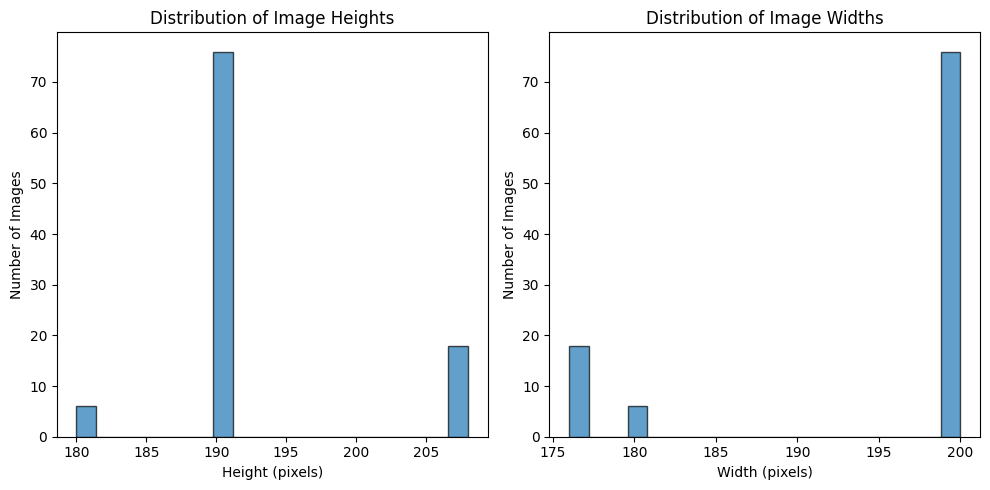

In [13]:
# Count and visualize the most frequent MRI image dimensions across Alzheimer dataset samples
from collections import Counter


size_counts = Counter(dimension_pairs)

print("Most common image sizes:")
print("-" * 30)


for size, count in size_counts.most_common(5):
    percentage = (count / len(sample_images)) * 100
    print(f"{size}: {count} images ({percentage:.1f}%)")


plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.hist(heights, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Height (pixels)')
plt.ylabel('Number of Images')
plt.title('Distribution of Image Heights')

plt.subplot(1, 2, 2)
plt.hist(widths, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Width (pixels)')
plt.ylabel('Number of Images')
plt.title('Distribution of Image Widths')

plt.tight_layout()
plt.show()

In [14]:
# Extract and summarize basic numerical features from 50 random images per Alzheimer class
def extract_simple_features(img_path):
    """Extract ONLY numerical features from an image"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    features = {}
    
    # Only numerical features
    features['height'] = float(img.shape[0])
    features['width'] = float(img.shape[1])
    features['mean_intensity'] = float(np.mean(img))
    features['std_intensity'] = float(np.std(img))
    
    # Grayscale features
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    features['gray_mean'] = float(np.mean(gray))
    features['gray_std'] = float(np.std(gray))
    
    return features


In [15]:
features_data = []

samples_per_class = 50

for class_name in classes:
    print(f"  {class_name}...")
    
    class_path = os.path.join(Alzheimer_df, class_name)
    all_images = os.listdir(class_path)
    sample_images = random.sample(all_images, min(samples_per_class, len(all_images)))
    
    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        
        try:
            features = extract_simple_features(img_path)
            features['class'] = class_name
            features_data.append(features)
        except:
            continue

# Create DataFrame
features_df = pd.DataFrame(features_data)

print(f"\n✓ Extracted {len(features_df)} samples")
print(f"Features: {list(features_df.columns)}")

  ModerateDemented...
  NonDemented...
  VeryMildDemented...
  MildDemented...

✓ Extracted 200 samples
Features: ['height', 'width', 'mean_intensity', 'std_intensity', 'gray_mean', 'gray_std', 'class']


In [16]:
summary_data = []

for class_name in classes:
    class_data = features_df[features_df['class'] == class_name]
    
    summary_data.append({
        'Class': class_name,
        'Images': len(class_data),
        'Mean Intensity': f"{class_data['mean_intensity'].median():.1f}",
        'Std Intensity': f"{class_data['std_intensity'].median():.1f}",
        'Gray Mean': f"{class_data['gray_mean'].median():.1f}",
        'Gray Std': f"{class_data['gray_std'].median():.1f}"
    })

# Create and display DataFrame
summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))





           Class  Images Mean Intensity Std Intensity Gray Mean Gray Std
ModerateDemented      50           69.5          78.0      68.9     78.1
     NonDemented      50           77.5          82.4      77.5     82.1
VeryMildDemented      50           75.9          81.2      75.9     81.2
    MildDemented      50           70.6          80.7      70.2     80.8


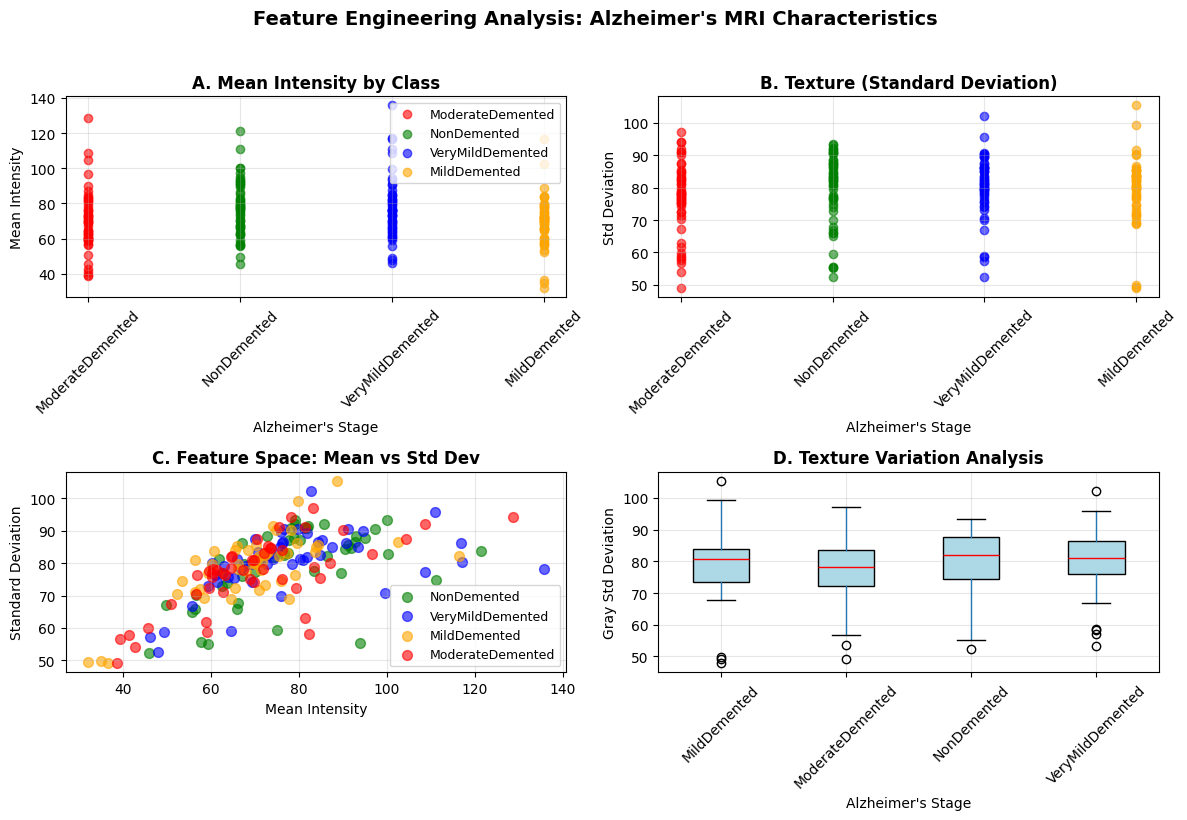

In [17]:
# Visualize intensity and texture differences between Alzheimer stages through 4 comparative plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

colors = {
    'NonDemented': 'green',
    'VeryMildDemented': 'blue', 
    'MildDemented': 'orange',
    'ModerateDemented': 'red'
}


plot_configs = [
    (0, 0, 'mean_intensity', 'A. Mean Intensity by Class', 'Mean Intensity'),
    (0, 1, 'std_intensity', 'B. Texture (Standard Deviation)', 'Std Deviation'),
]

# Plot scatter plots (first two plots)
for ax_row, ax_col, feature, title, ylabel in plot_configs:
    ax = axes[ax_row, ax_col]
    
    for i, class_name in enumerate(classes):
        class_data = features_df[features_df['class'] == class_name]
        ax.scatter([i] * len(class_data), 
                  class_data[feature], 
                  alpha=0.6, 
                  label=class_name if ax_col == 0 else None,  # Label only in first plot
                  color=colors[class_name])
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Alzheimer\'s Stage', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45)
    if ax_col == 0:
        ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Plot 3: Feature space scatter plot
for class_name, color in colors.items():
    class_data = features_df[features_df['class'] == class_name]
    axes[1, 0].scatter(class_data['mean_intensity'], 
                      class_data['std_intensity'], 
                      alpha=0.6, 
                      label=class_name, 
                      color=color,
                      s=50)

axes[1, 0].set_title('C. Feature Space: Mean vs Std Dev', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mean Intensity', fontsize=10)
axes[1, 0].set_ylabel('Standard Deviation', fontsize=10)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Box plot
features_df.boxplot(column='gray_std', by='class', ax=axes[1, 1], 
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='black'),
                   medianprops=dict(color='red'))
axes[1, 1].set_title('D. Texture Variation Analysis', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Gray Std Deviation', fontsize=10)
axes[1, 1].set_xlabel('Alzheimer\'s Stage', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# Overall title
plt.suptitle('Feature Engineering Analysis: Alzheimer\'s MRI Characteristics', 
             fontsize=14, y=1.02, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_analysis_simple.png', dpi=100, bbox_inches='tight')
plt.show()


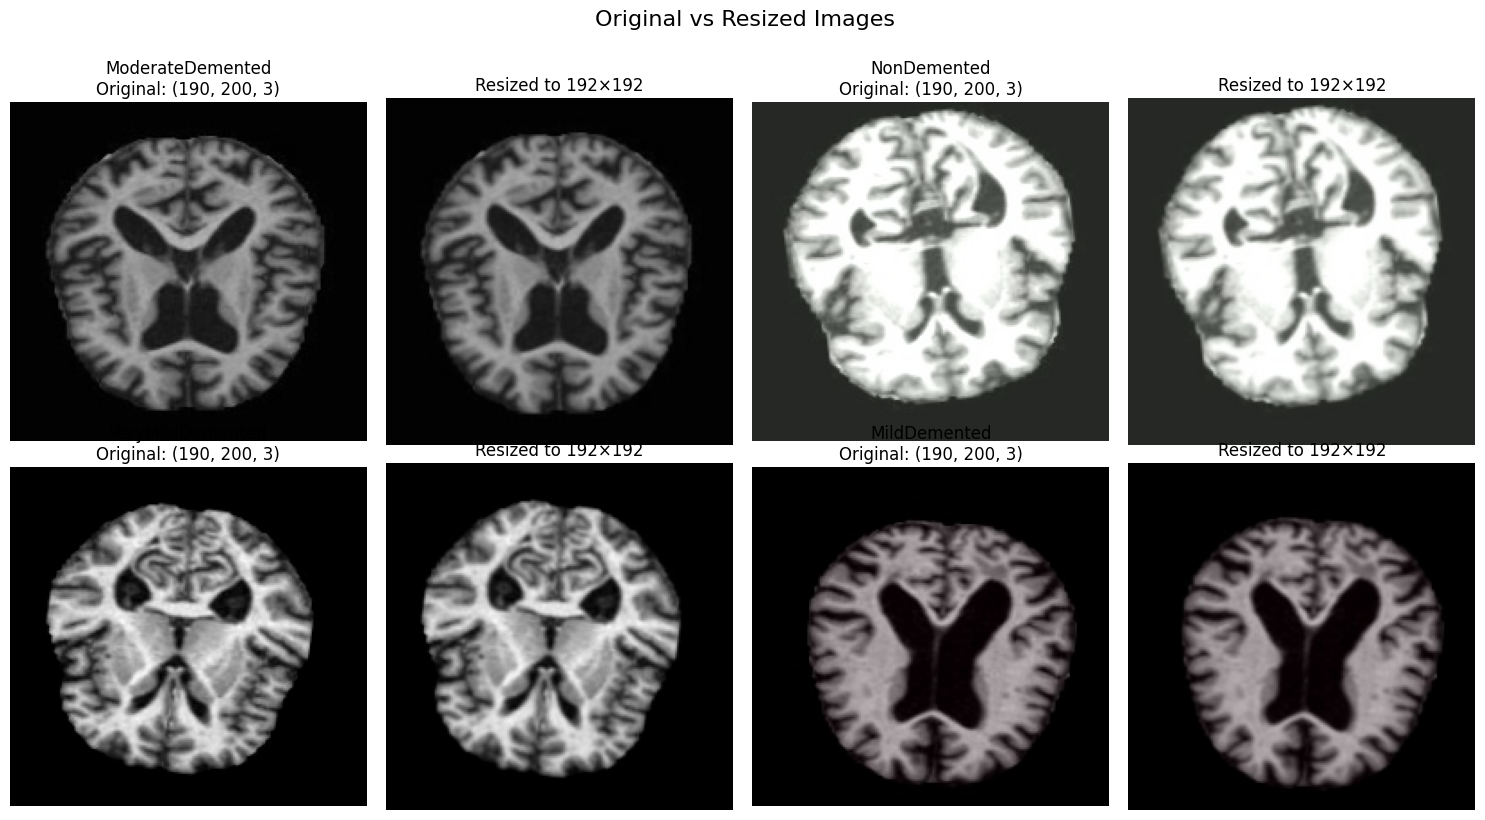

In [18]:

# Compare original MRI dimensions with resized versions to verify preprocessing integrity
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for i, class_name in enumerate(classes):
    
    class_folder = os.path.join(Alzheimer_df, class_name)
    random_image = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, random_image)
    
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    
    
    row = i // 2
    col = (i % 2) * 2
    axes[row, col].imshow(img)
    axes[row, col].set_title(f'{class_name}\nOriginal: {img.shape}')
    axes[row, col].axis('off')

    IMG_SIZE = 192 
    
    
    resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    axes[row, col + 1].imshow(resized_img)
    axes[row, col + 1].set_title(f'Resized to {IMG_SIZE}×{IMG_SIZE}')
    axes[row, col + 1].axis('off')

plt.suptitle('Original vs Resized Images', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [19]:
# We need to organize ALL 44,000 images, not just samples
print("Creating complete dataset dataframe...")

data = []
for class_idx, class_name in enumerate(classes):
    class_path = os.path.join(Alzheimer_df, class_name)
    image_files = os.listdir(class_path)
    
    print(f"Processing {class_name}... ({len(image_files)} images)")
    
    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        data.append([img_path, class_name, class_idx])

# Create the dataframe
df = pd.DataFrame(data, columns=['filepath', 'class_name', 'label'])

print(f"\n✓ DataFrame created with {len(df)} total images")
print("\nClass distribution:")
print(df['class_name'].value_counts())

# Show first few rows
print("\nFirst 5 rows:")
print(df.head())

Creating complete dataset dataframe...
Processing ModerateDemented... (10000 images)
Processing NonDemented... (12800 images)
Processing VeryMildDemented... (11200 images)
Processing MildDemented... (10000 images)

✓ DataFrame created with 44000 total images

Class distribution:
class_name
NonDemented         12800
VeryMildDemented    11200
ModerateDemented    10000
MildDemented        10000
Name: count, dtype: int64

First 5 rows:
                                            filepath        class_name  label
0  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented      0
1  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented      0
2  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented      0
3  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented      0
4  /kaggle/input/alzheimers-multiclass-dataset-eq...  ModerateDemented      0


In [20]:


# Split Alzheimer MRI dataset into stratified train/validation/test sets (70%/15%/15%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['class_name']
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['class_name']
)

print(f"Training set: {len(train_df):,} images")
print(f"Validation set: {len(val_df):,} images")
print(f"Test set: {len(test_df):,} images")



Training set: 30,800 images
Validation set: 6,600 images
Test set: 6,600 images


In [26]:
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 192
BATCH_SIZE = 32  

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator_resnet = train_datagen_resnet.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='class_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator_resnet = val_test_datagen_resnet.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='class_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 30800 validated image filenames belonging to 4 classes.
Found 6600 validated image filenames belonging to 4 classes.


In [27]:
# Build ResNet50-based transfer learning model for Alzheimer's 4-class MRI classification
resnet_model = models.Sequential([
    ResNet50(weights='imagenet', include_top=False, 
             input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])


resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,772,228 (94.50 MB)

 Trainable params: 24,717,572 (94.29 MB)

 Non-trainable params: 54,656 (213.50 KB)

In [28]:
# Compile ResNet50 Alzheimer model with low learning rate and categorical classification 
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Learning rate: 0.0001 (lower for transfer learning)")

Learning rate: 0.0001 (lower for transfer learning)


In [29]:
# Configure callbacks for early stopping, model checkpointing, and learning rate reduction
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

os.makedirs('resnet_models', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'resnet_models/best_resnet50_improved.keras',  
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

os.makedirs('resnet_models', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'resnet_models/best_resnet50_improved.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [31]:
EPOCHS = 15
train_steps = len(train_df) // BATCH_SIZE
val_steps = len(val_df) // BATCH_SIZE

print(f"Training steps per epoch: {train_steps}")
print(f"Validation steps: {val_steps}")

resnet_history = resnet_model.fit(
    train_generator_resnet,      
    steps_per_epoch=train_steps,
    validation_data=val_generator_resnet,  
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Training steps per epoch: 962
Validation steps: 206
Epoch 1/15
962/962 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5045 - loss: 1.3351
Epoch 1: val_accuracy improved from -inf to 0.75046, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 375s 332ms/step - accuracy: 0.5046 - loss: 1.3347 - val_accuracy: 0.7505 - val_loss: 0.5544 - learning_rate: 1.0000e-04
Epoch 2/15
  1/962 ━━━━━━━━━━━━━━━━━━━━ 3:41 230ms/step - accuracy: 0.7188 - loss: 0.7887
Epoch 2: val_accuracy improved from 0.75046 to 0.75152, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.7188 - loss: 0.7887 - val_accuracy: 0.7515 - val_loss: 0.5541 - learning_rate: 1.0000e-04
Epoch 3/15
962/962 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7231 - loss: 0.6354
Epoch 3: val_accuracy improved from 0.75152 to 0.82266, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 291s 303ms/step - accuracy: 0.7231 - loss: 0.6353 - val_accuracy: 0.8227 - val_loss: 0.4234 - learning_rate: 1.0000e-04
Epoch 4/15
  1/962 ━━━━━━━━━━━━━━━━━━━━ 3:30 219ms/step - accuracy: 0.8125 - loss: 0.4204
Epoch 4: val_accuracy improved from 0.82266 to 0.82464, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8125 - loss: 0.4204 - val_accuracy: 0.8246 - val_loss: 0.4168 - learning_rate: 1.0000e-04
Epoch 5/15
962/962 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8202 - loss: 0.4343
Epoch 5: val_accuracy did not improve from 0.82464
962/962 ━━━━━━━━━━━━━━━━━━━━ 299s 310ms/step - accuracy: 0.8202 - loss: 0.4343 - val_accuracy: 0.8230 - val_loss: 0.4437 - learning_rate: 1.0000e-04
Epoch 6/15
  1/962 ━━━━━━━━━━━━━━━━━━━━ 3:31 220ms/step - accuracy: 0.7812 - loss: 0.4233
Epoch 6: val_accuracy improved from 0.82464 to 0.82919, saving model to resnet_models/best_resnet50_improved.h5


...

962/962 ━━━━━━━━━━━━━━━━━━━━ 286s 297ms/step - accuracy: 0.9174 - loss: 0.2234 - val_accuracy: 0.9170 - val_loss: 0.2039 - learning_rate: 1.0000e-04
Epoch 10/15
  1/962 ━━━━━━━━━━━━━━━━━━━━ 3:33 222ms/step - accuracy: 0.9688 - loss: 0.0720
Epoch 10: val_accuracy improved from 0.91702 to 0.91945, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9688 - loss: 0.0720 - val_accuracy: 0.9194 - val_loss: 0.1965 - learning_rate: 1.0000e-04
Epoch 11/15
962/962 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9342 - loss: 0.1815
Epoch 11: val_accuracy improved from 0.91945 to 0.94554, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 287s 298ms/step - accuracy: 0.9343 - loss: 0.1815 - val_accuracy: 0.9455 - val_loss: 0.1494 - learning_rate: 1.0000e-04
Epoch 12/15
  1/962 ━━━━━━━━━━━━━━━━━━━━ 3:30 219ms/step - accuracy: 0.9375 - loss: 0.2090
Epoch 12: val_accuracy did not improve from 0.94554
962/962 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9375 - loss: 0.2090 - val_accuracy: 0.9452 - val_loss: 0.1524 - learning_rate: 1.0000e-04
Epoch 13/15
962/962 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9484 - loss: 0.1441
Epoch 13: val_accuracy improved from 0.94554 to 0.97573, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 285s 296ms/step - accuracy: 0.9484 - loss: 0.1441 - val_accuracy: 0.9757 - val_loss: 0.0671 - learning_rate: 1.0000e-04
Epoch 14/15
  1/962 ━━━━━━━━━━━━━━━━━━━━ 3:32 221ms/step - accuracy: 0.9688 - loss: 0.1694
Epoch 14: val_accuracy improved from 0.97573 to 0.97664, saving model to resnet_models/best_resnet50_improved.h5


962/962 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9688 - loss: 0.1694 - val_accuracy: 0.9766 - val_loss: 0.0682 - learning_rate: 1.0000e-04
Epoch 15/15
962/962 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9575 - loss: 0.1228
Epoch 15: val_accuracy did not improve from 0.97664
962/962 ━━━━━━━━━━━━━━━━━━━━ 281s 292ms/step - accuracy: 0.9575 - loss: 0.1228 - val_accuracy: 0.9343 - val_loss: 0.1778 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 13.


In [32]:
# Create test data generator for evaluating final Alzheimer model performance
test_generator_resnet = val_test_datagen_resnet.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='class_name',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  
)

print(f"Test batches: {len(test_generator_resnet)}")
print(f"Test classes: {test_generator_resnet.class_indices}")

Found 6600 validated image filenames belonging to 4 classes.
Test batches: 207
Test classes: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


In [33]:
# Load best saved model and evaluate on Alzheimer MRI test set for final accuracy metrics
best_resnet = tf.keras.models.load_model('resnet_models/best_resnet50_improved.h5')


best_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


test_steps = len(test_df) // BATCH_SIZE


test_loss, test_accuracy = best_resnet.evaluate(
    test_generator_resnet,
    steps=test_steps,
    verbose=1
)


print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"Test Loss: {test_loss:.4f}")



206/206 ━━━━━━━━━━━━━━━━━━━━ 33s 133ms/step - accuracy: 0.9779 - loss: 0.0683
Test Accuracy: 0.9785 (97.8%)
Test Loss: 0.0673


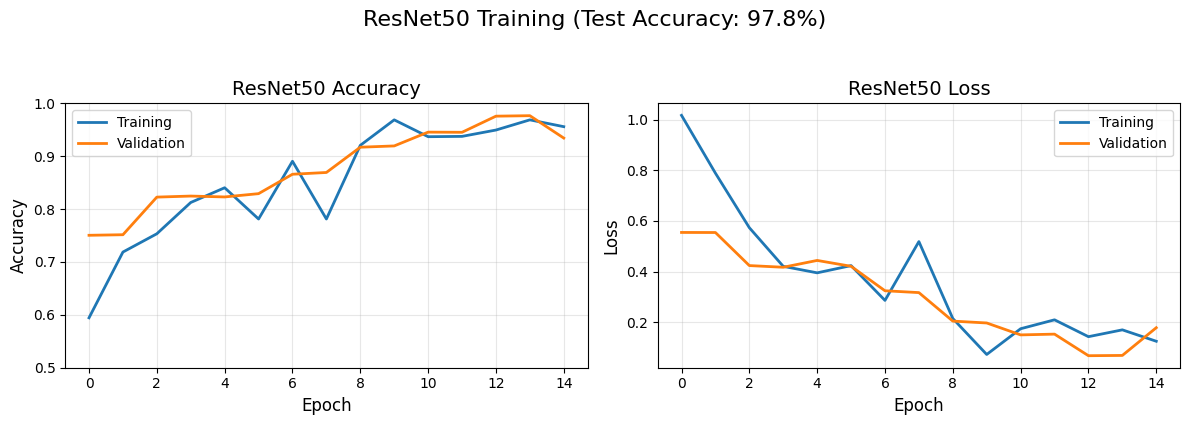

In [34]:


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(resnet_history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(resnet_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('ResNet50 Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.5, 1.0])

# Loss plot
axes[1].plot(resnet_history.history['loss'], label='Training', linewidth=2)
axes[1].plot(resnet_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('ResNet50 Loss', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'ResNet50 Training (Test Accuracy: {test_accuracy*100:.1f}%)', 
             fontsize=16, y=1.05)
plt.tight_layout()
plt.show()



In [35]:
predictions = best_resnet.predict(test_generator_resnet, verbose=1)


predicted_classes = np.argmax(predictions, axis=1)


true_classes = np.array(test_generator_resnet.classes)
class_names = list(test_generator_resnet.class_indices.keys())

print(f"✓ Predictions generated for {len(predicted_classes)} test images")
print(f"Class names: {class_names}")
print(f"True classes: {len(true_classes)} samples")
print(f"Predicted classes: {len(predicted_classes)} samples")


accuracy = np.mean(true_classes == predicted_classes)
print(f"Calculated accuracy: {accuracy:.4f} (matches {test_accuracy:.4f} from evaluate())")

207/207 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step
✓ Predictions generated for 6600 test images
Class names: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
True classes: 6600 samples
Predicted classes: 6600 samples
Calculated accuracy: 0.9785 (matches 0.9785 from evaluate())


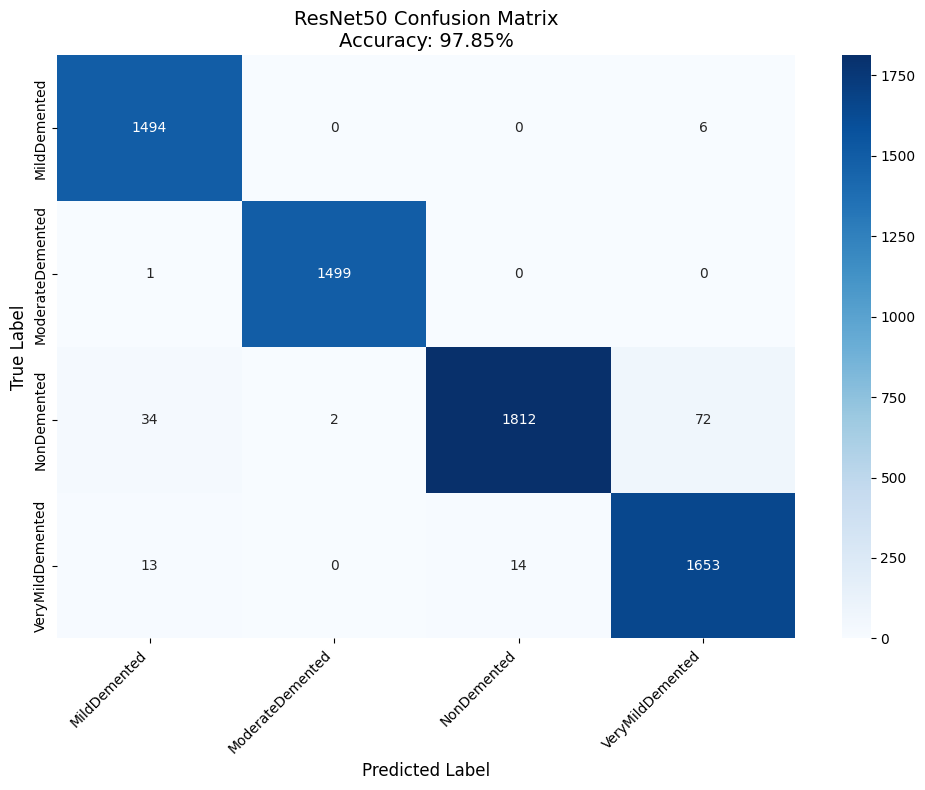

Classification Report:
                  precision    recall  f1-score   support

    MildDemented      0.969     0.996     0.982      1500
ModerateDemented      0.999     0.999     0.999      1500
     NonDemented      0.992     0.944     0.967      1920
VeryMildDemented      0.955     0.984     0.969      1680

        accuracy                          0.978      6600
       macro avg      0.979     0.981     0.979      6600
    weighted avg      0.979     0.978     0.978      6600



In [36]:
# confusion matrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


cm = confusion_matrix(true_classes, predicted_classes)


total = cm.sum()
correct = cm.diagonal().sum()
accuracy = correct / total


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title(f'ResNet50 Confusion Matrix\nAccuracy: {accuracy:.2%}', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(true_classes, predicted_classes, 
                           target_names=class_names, digits=3))

In [37]:
def simple_gradcam(model, img_array):
    
    
    last_conv = model.layers[-3]  
    
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv.output, model.output]
    )
    
    
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        loss = predictions[:, tf.argmax(predictions[0])]
    
    
    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_output = conv_output[0]
    heatmap = tf.reduce_mean(conv_output * pooled_grads, axis=-1)
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    
    return heatmap.numpy()

def overlay_heatmap(img, heatmap):
    """Simple heatmap overlay"""
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    

    result = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)
    return result


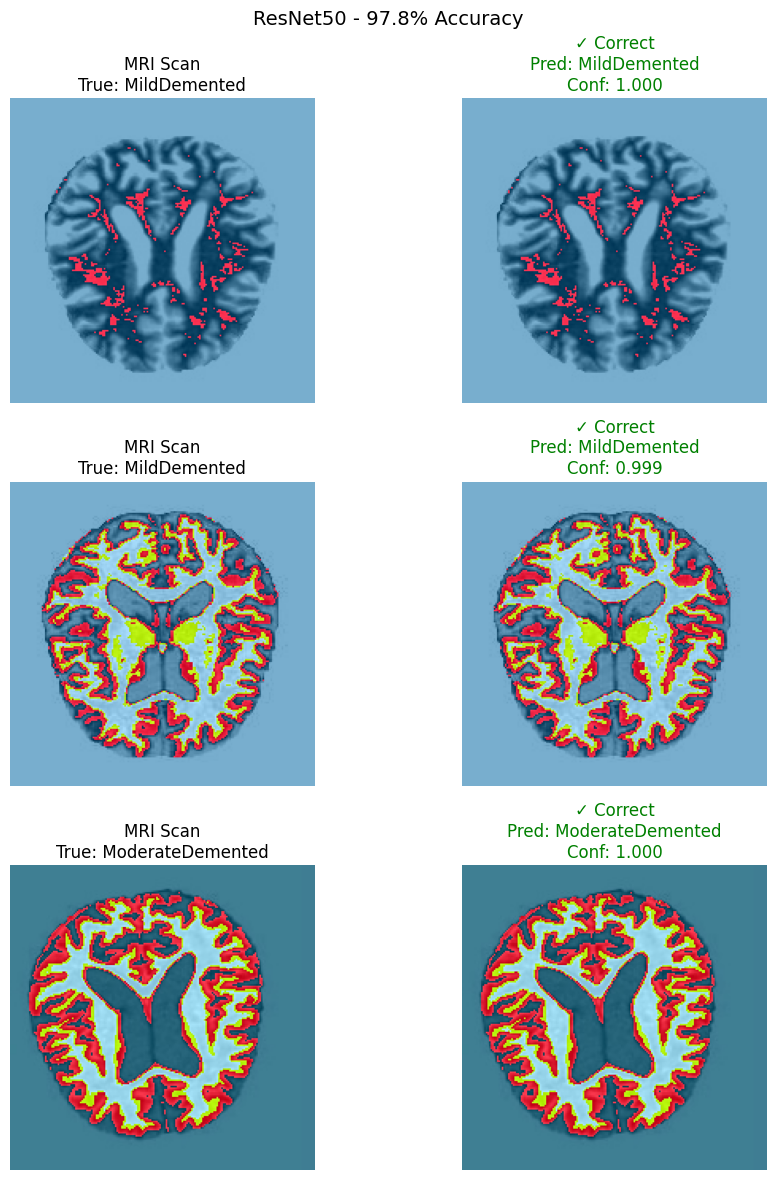

In [38]:
test_generator_resnet.reset()
images, labels = next(test_generator_resnet)
images = images[:3]
true_labels = np.argmax(labels[:3], axis=1)


preds = best_resnet.predict(images, verbose=0)
pred_labels = np.argmax(preds, axis=1)


fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i in range(3):

    img = (images[i] * 255).astype(np.uint8)
    
    true_class = class_names[true_labels[i]]
    pred_class = class_names[pred_labels[i]]
    confidence = np.max(preds[i])
    correct = true_labels[i] == pred_labels[i]
    
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'MRI Scan\nTrue: {true_class}', fontsize=12)
    axes[i, 0].axis('off')
    
    
    color = 'green' if correct else 'red'
    axes[i, 1].imshow(img)
    status = "✓ Correct" if correct else "✗ Wrong"
    axes[i, 1].set_title(f'{status}\nPred: {pred_class}\nConf: {confidence:.3f}', 
                        fontsize=12, color=color)
    axes[i, 1].axis('off')

plt.suptitle(f'ResNet50 - {test_accuracy:.1%} Accuracy', fontsize=14)
plt.tight_layout()
plt.show()